# Load and Explore the dataset

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd 
import numpy as np

In [2]:
G = nx.read_edgelist(
    "congress.edgelist",
    create_using=nx.DiGraph(),
    nodetype=int
)

In [3]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print(f"Nodes range: {min(G.nodes()), max(G.nodes())}")

Nodes: 475
Edges: 13289
Nodes range: (0, 474)


In [4]:
# retrieve self loops and isolated nodes
# remove self loops 

self_loops = list(nx.selfloop_edges(G))
print("Self loops:", len(self_loops))

isolates = list(nx.isolates(G))
print(f"Isolated nodes: {len(isolates)}")

G.remove_edges_from(self_loops)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")


Self loops: 0
Isolated nodes: 0
Nodes: 475, Edges: 13289


In [5]:
import json

with open("congress_network_data.json") as f:
    data = json.load(f)

data = data[0]  

username_list = data["usernameList"]

node_to_username = dict(enumerate(username_list))

nx.set_node_attributes(G, node_to_username, "label")

## Descriptive Metrics

In [6]:
# Characteristics of the network
density = nx.density(G)
global_reciprocity = nx.reciprocity(G)

print("Is directed:", nx.is_directed(G))
print(f"Density: {density:.4f}")
print("Is strongly connected:", nx.is_strongly_connected(G))
print(f"Global reciprocity: {global_reciprocity:.4f}")

Is directed: True
Density: 0.0590
Is strongly connected: False
Global reciprocity: 0.4616


#### Connected components

In [7]:
# 5.1 Weakly and strongly connected components
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wcc], reverse=True)
wcc_sizes = []
for c in wcc:
    wcc_sizes.append(len(c))
wcc_sizes = sorted(wcc_sizes,reverse=True)
#wcc_sizes.sort(reverse=True)

scc = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in scc], reverse=True)


# 5.2 Analyze size

print(f"Number of weakly connected components: {len(wcc)}")
print(f"    Sizes of the 5 largest WCCs: {wcc_sizes[:5]}")

print(f"Number of strongly connected components: {len(scc)}")
print(f"    Sizes of the 5 largest SCCs: {scc_sizes[:5]}")

Number of weakly connected components: 1
    Sizes of the 5 largest WCCs: [475]
Number of strongly connected components: 7
    Sizes of the 5 largest SCCs: [469, 1, 1, 1, 1]


#### Degree Distribution

In [8]:
# 2.1 Compute in-degree and out-degree
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

# Convert to pandas DataFrame for convenience
deg_df = pd.DataFrame({
    "node": list(G.nodes()),
    "in_degree": [in_degrees[n] for n in G.nodes()],
    "out_degree": [out_degrees[n] for n in G.nodes()]
})
deg_df["total_degree"] = deg_df["in_degree"] + deg_df["out_degree"]

deg_df.sort_values("total_degree", ascending=False).head()

,node,in_degree,out_degree,total_degree
270,322,127,157,284
121,367,51,210,261
88,393,79,111,190
51,254,108,79,187
313,208,121,61,182


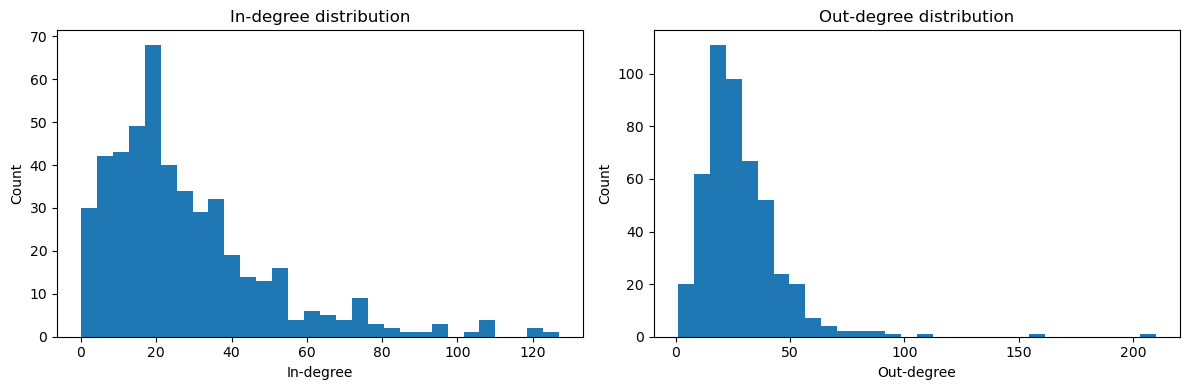

In [9]:
# 2.2 Plot in-degree and out-degree distributions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(deg_df["in_degree"], bins=30)
axes[0].set_title("In-degree distribution")
axes[0].set_xlabel("In-degree")
axes[0].set_ylabel("Count")

axes[1].hist(deg_df["out_degree"], bins=30)
axes[1].set_title("Out-degree distribution")
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

#### Clustering coefficient

In [10]:
# 6.1 Convert to undirected for clustering measures
G_und = G.to_undirected()

# 6.2 Compute global metrics
global_clustering = nx.transitivity(G_und)
avg_local_clustering = nx.average_clustering(G_und)

print(f"Global clustering coefficient (transitivity): {global_clustering:.4f}")
print(f"Average local clustering: {avg_local_clustering:.4f}")

Global clustering coefficient (transitivity): 0.2695
Average local clustering: 0.3014


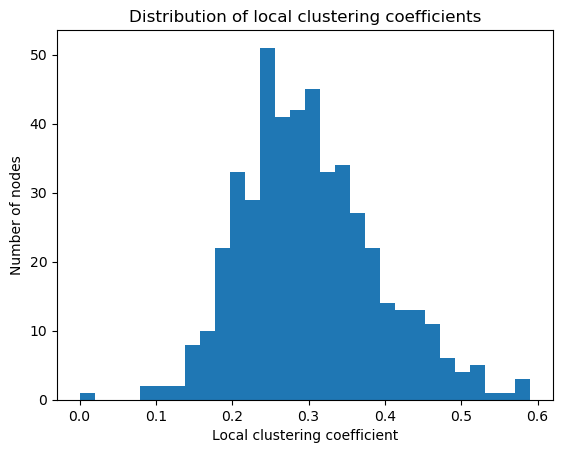

In [11]:
# 6.3 Distribution of local clustering coefficients

clustering_dict = nx.clustering(G_und)
clustering_values = list(clustering_dict.values())

plt.hist(clustering_values, bins=30)
plt.xlabel("Local clustering coefficient")
plt.ylabel("Number of nodes")
plt.title("Distribution of local clustering coefficients")
plt.show()

#### Bridges

In [12]:
# 7.1 unidrected graph (already obtained in 6.1)

# 7.2 Compute bridges
bridges = list(nx.bridges(G_und))
print(f"Number of bridges in the undirected graph: {len(bridges)} ({round(len(bridges)/G_und.size()*100,2)}% of edges)")

# Show a few bridges
print("Sample bridges:", bridges[:10])

# 7.3 Compute bridges
local_bridges = list(nx.local_bridges(G_und, with_span = False))
print(f"Number of local bridges in the undirected graph: {len(local_bridges)} - ({round(len(local_bridges)/G_und.size()*100,2)}% of edges)")

# Show a few bridges
print("Sample local bridges:", local_bridges[:10])



Number of bridges in the undirected graph: 0 (0.0% of edges)
Sample bridges: []
Number of local bridges in the undirected graph: 94 - (0.92% of edges)
Sample local bridges: [(18, 217), (58, 381), (76, 336), (341, 419), (17, 152), (79, 396), (79, 407), (213, 240), (250, 69), (250, 406)]


#### Comment
The undirected network contains no bridges, indicating that no single edge is structurally critical for maintaining global connectivity. This suggests a highly redundant structure with multiple alternative paths between nodes. However, 94 local bridges (0.92% of edges) are present, representing ties that connect otherwise unshared neighborhoods and potentially linking different communities.

#### Centrality Measures

In [13]:
# 9.1 Degree centrality (computed on undirected version)
deg_cent = nx.degree_centrality(G_und)

# 9.2 Betweenness centrality
bet_cent = nx.betweenness_centrality(G_und, normalized=True)

# 9.3 Closeness centrality
clo_cent = nx.closeness_centrality(G_und)

# 9.4 PageRank (directed)
pr = nx.pagerank(G, alpha=0.85)

# 9.5 In-degree and out-degree
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

# 9.6 Build centrality dataframe
centrality_df = pd.DataFrame({
    "node": list(G.nodes()),
    "degree_centrality": [deg_cent[n] for n in G.nodes()],
    "betweenness_centrality": [bet_cent[n] for n in G.nodes()],
    "closeness_centrality": [clo_cent[n] for n in G.nodes()],
    "pagerank": [pr[n] for n in G.nodes()],
    "in_degree": [in_deg[n] for n in G.nodes()],
    "out_degree": [out_deg[n] for n in G.nodes()]
})

# 9.7 Add node labels (Twitter usernames)
labels = nx.get_node_attributes(G, "label")
centrality_df["label"] = centrality_df["node"].map(labels)

# 9.8 Quick look
centrality_df.sort_values("pagerank", ascending=False).head(10)

,node,degree_centrality,betweenness_centrality,closeness_centrality,pagerank,in_degree,out_degree,label
270,322,0.381857,0.037183,0.617188,0.016696,127,157,GOPLeader
81,147,0.219409,0.007614,0.549247,0.012845,97,51,RepCasten
105,389,0.194093,0.005526,0.547977,0.011028,84,55,RepChipRoy
298,269,0.236287,0.007737,0.555035,0.010660,106,57,RepMikeJohnson
84,215,0.177215,0.004055,0.544202,0.010580,76,45,RepChuyGarcia
313,208,0.282700,0.015459,0.570397,0.008885,121,61,RepFranklin
126,92,0.221519,0.013185,0.558304,0.008246,94,44,RepAdams
101,246,0.132911,0.002414,0.522602,0.008157,59,29,CongressmanHice
207,303,0.217300,0.009322,0.546713,0.008033,97,66,RepAndyLevin
287,113,0.204641,0.007742,0.551163,0.008026,77,65,RepAndyBiggsAZ


In [59]:
# Key nodes

def show_top(df, col, k=10):
    print(f"\nTop {k} nodes by {col}:")
    display(
        df.sort_values(col, ascending=False)
          .reset_index(drop=True)
          .head(k)[["node", "label", col, "in_degree", "out_degree"]]
    )

show_top(centrality_df, "degree_centrality")
show_top(centrality_df, "betweenness_centrality")
show_top(centrality_df, "closeness_centrality")
show_top(centrality_df, "pagerank")


Top 10 nodes by degree_centrality:


,node,label,degree_centrality,in_degree,out_degree
0,367,SpeakerPelosi,0.451477,51,210
1,322,GOPLeader,0.381857,127,157
2,254,LeaderHoyer,0.299578,108,79
3,208,RepFranklin,0.282700,121,61
4,393,RepBobbyRush,0.272152,79,111
5,190,RepJeffDuncan,0.267932,120,37
6,111,RepDonBeyer,0.253165,109,39
7,192,RepTomEmmer,0.238397,105,43
8,269,RepMikeJohnson,0.236287,106,57
9,385,RepJohnRose,0.234177,108,20



Top 10 nodes by betweenness_centrality:


,node,label,betweenness_centrality,in_degree,out_degree
0,367,SpeakerPelosi,0.068626,51,210
1,322,GOPLeader,0.037183,127,157
2,254,LeaderHoyer,0.022623,108,79
3,208,RepFranklin,0.015459,121,61
4,17,JohnCornyn,0.014895,72,51
5,71,SenSchumer,0.013771,25,97
6,393,RepBobbyRush,0.013559,79,111
7,461,RepBonnie,0.013285,75,62
8,92,RepAdams,0.013185,94,44
9,190,RepJeffDuncan,0.013048,120,37



Top 10 nodes by closeness_centrality:


,node,label,closeness_centrality,in_degree,out_degree
0,367,SpeakerPelosi,0.645777,51,210
1,322,GOPLeader,0.617188,127,157
2,254,LeaderHoyer,0.585185,108,79
3,111,RepDonBeyer,0.571084,109,39
4,393,RepBobbyRush,0.570397,79,111
5,208,RepFranklin,0.570397,121,61
6,461,RepBonnie,0.561611,75,62
7,92,RepAdams,0.558304,94,44
8,190,RepJeffDuncan,0.557647,120,37
9,71,SenSchumer,0.556338,25,97



Top 10 nodes by pagerank:


,node,label,pagerank,in_degree,out_degree
0,322,GOPLeader,0.016696,127,157
1,147,RepCasten,0.012845,97,51
2,389,RepChipRoy,0.011028,84,55
3,269,RepMikeJohnson,0.010660,106,57
4,215,RepChuyGarcia,0.010580,76,45
5,208,RepFranklin,0.008885,121,61
6,92,RepAdams,0.008246,94,44
7,246,CongressmanHice,0.008157,59,29
8,303,RepAndyLevin,0.008033,97,66
9,113,RepAndyBiggsAZ,0.008026,77,65


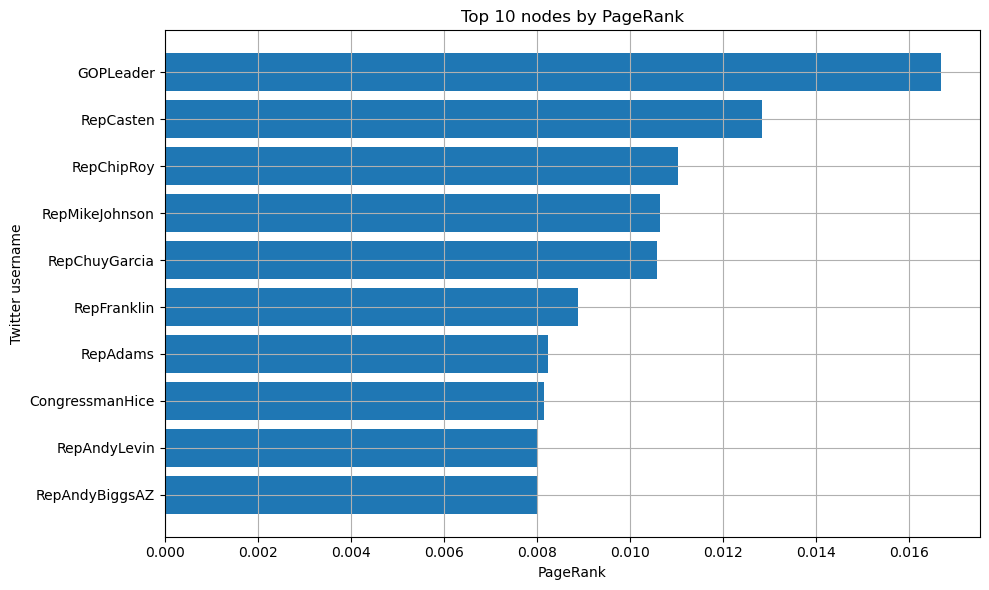

In [60]:
# Barplot of top 10 nodes by PageRank

top10_pr = (
    centrality_df.sort_values("pagerank", ascending=False)
    .head(10)
    .sort_values("pagerank", ascending=True)   # for horizontal barplot
)

plt.figure(figsize=(10, 6))
plt.barh(top10_pr["label"], top10_pr["pagerank"])
plt.xlabel("PageRank")
plt.ylabel("Twitter username")
plt.title("Top 10 nodes by PageRank")
plt.tight_layout()
plt.show()

### Comment
The PageRank ranking highlights a small set of highly influential congressional Twitter accounts. The account GOPLeader emerges as the most central node in the network, indicating that many interactions originate from or target this account. The presence of several Republican representatives among the top-ranked nodes suggests that one of the detected communities likely corresponds to the Republican political cluster. At the same time, the presence of Democratic accounts among the most central nodes indicates that interactions across political groups are still present within the network structure.

#### Community Detection

In [ ]:
from networkx.algorithms.community import louvain_communities

################
# check whether it is useful
# from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

print("Running Louvain community detection...")
louvain_comms = louvain_communities(G_und, seed=42)

print(f"Detected {len(louvain_comms)} communities.")

Running Louvain community detection...
Detected 4 communities.


In [66]:
# Node -> community mapping
community_map = {}

for i, comm in enumerate(louvain_comms):
    for node in comm:
        community_map[node] = i

centrality_df["community"] = centrality_df["node"].map(community_map)

nx.set_node_attributes(G, community_map, "community")
nx.set_node_attributes(G_und, community_map, "community")

In [20]:
nx.write_graphml(G_und, "congress_network.graphml")

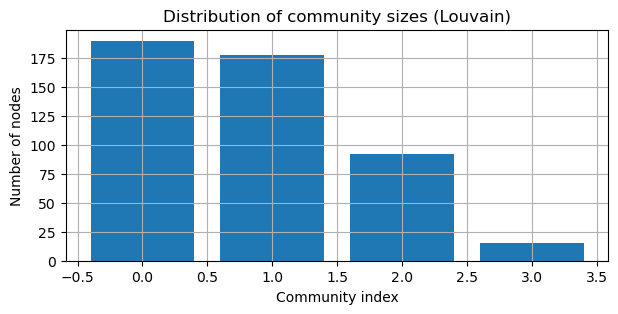

Number of communities: 4
Smallest community: 15 nodes
Largest community: 190 nodes


In [21]:
# Compute community sizes
community_sizes = sorted([len(c) for c in louvain_comms], reverse = True)

# Plot histogram
plt.figure(figsize=(7,3))
plt.bar(range(len(community_sizes)),community_sizes)
plt.xlabel("Community index")
plt.ylabel("Number of nodes")
plt.title("Distribution of community sizes (Louvain)")
plt.grid(True)
plt.show()

# Print summary stats
print(f"Number of communities: {len(community_sizes)}")
print(f"Smallest community: {min(community_sizes)} nodes")
print(f"Largest community: {max(community_sizes)} nodes")

In [67]:
# Avg centrality measures by community
centrality_df.groupby("community").agg(
    n_nodes=("node", "count"),
    avg_pagerank=("pagerank", "mean"),
    avg_degree=("degree_centrality", "mean"),
    max_pagerank=("pagerank", "max")
).sort_values("avg_pagerank", ascending=False)

,n_nodes,avg_pagerank,avg_degree,max_pagerank
community,,,,
3,178,0.002382,0.093609,0.016696
0,190,0.002204,0.095803,0.012845
2,15,0.001870,0.071027,0.005226
1,92,0.001403,0.078265,0.005677


In [23]:
# Assortativity
nx.attribute_assortativity_coefficient(G_und, "community")

0.6089383686206323

##### Comment
The degree assortativity coefficient is 0.61, indicating a strongly assortative network. This means that nodes tend to connect with other nodes having a similar degree, suggesting that highly connected nodes preferentially interact with other highly connected nodes, while low-degree nodes tend to link to similarly less connected nodes.

[[0.33036588 0.04294659 0.00997848 0.03873997]
 [0.04294659 0.09577382 0.00523381 0.02298963]
 [0.00997848 0.00523381 0.00342399 0.00606535]
 [0.03873997 0.02298963 0.00606535 0.31852866]]


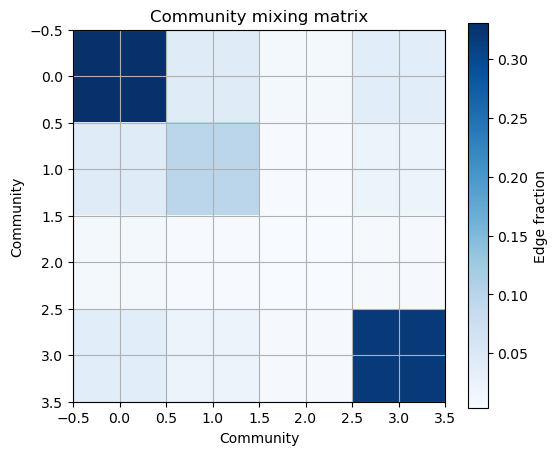

In [24]:
# links among communities
mix_matrix = nx.attribute_mixing_matrix(G_und, "community")

print(mix_matrix)

plt.figure(figsize=(6,5))
plt.imshow(mix_matrix, cmap="Blues")
plt.colorbar(label="Edge fraction")
plt.xlabel("Community")
plt.ylabel("Community")
plt.title("Community mixing matrix")
plt.show()

In [68]:
# Modularity score
from networkx.algorithms.community.quality import modularity

mod_score = modularity(G_und, louvain_comms)
mod_score_w = modularity(G_und, louvain_comms, weight="weight")

print(f"Unweighted modularity score: {mod_score:.4f}")
print(f"Weighted modularity score: {mod_score_w:.4f}")

Unweighted modularity score: 0.4385
Weighted modularity score: 0.4385


##### Comment
The modularity score is 0.4385, both in the weighted and unweighted cases. This relatively high value indicates a clear community structure in the network, with nodes forming well-defined modules that are more densely connected internally than with the rest of the network. The identical values suggest that edge weights do not substantially alter the detected community structure.

In [26]:
rows = []

for u, v in G.edges():
    rows.append({
        "source_node": u,
        "source_community": G.nodes[u].get("community"),
        "target_node": v,
        "target_community": G.nodes[v].get("community")
    })

edges_comm_df = pd.DataFrame(rows)

comm_flow_matrix = pd.crosstab(
    edges_comm_df["source_community"],
    edges_comm_df["target_community"]
).sort_index().sort_index(axis=1)

comm_flow_matrix

target_community,0,1,2,3
source_community,,,,
0,4388,403,146,489
1,711,1338,74,366
2,114,60,51,87
3,439,201,69,4353


In [27]:
total_edges = comm_flow_matrix.values.sum()
intra_edges = comm_flow_matrix.values.diagonal().sum()

print(f"Intra-community edges: {intra_edges/total_edges:.2%}")
print(f"Inter-community edges: {(total_edges-intra_edges)/total_edges:.2%}")

Intra-community edges: 76.23%
Inter-community edges: 23.77%


#### Comment
The directed community-to-community edge matrix reveals a clear modular structure in the network. Most edges occur within the same community, as shown by the large values along the diagonal, which is consistent with the overall distribution of edges: approximately 76.23% are intra-community, while 23.77% connect different communities. This indicates that nodes tend to interact primarily within their own module, confirming the presence of strong internal cohesion. At the same time, inter-community connections are not evenly distributed. In particular, communities 0 and 3 exchange the largest number of edges, suggesting that they form the main interface between otherwise densely connected parts of the network.

In [28]:
# Edge betweenness
edge_bet = nx.edge_betweenness_centrality(G_und, weight=None)

rows = []

for u, v, span in nx.local_bridges(G_und, with_span=True):
    
    rows.append({
        "source_node": u,
        "source_label": G_und.nodes[u].get("label", str(u)),
        "source_community": G_und.nodes[u].get("community"),
        "target_node": v,
        "target_label": G_und.nodes[v].get("label", str(v)),
        "target_community": G_und.nodes[v].get("community"),
        "same_community": G_und.nodes[u].get("community") == G_und.nodes[v].get("community"),
        "span": span,
        "edge_betweenness": edge_bet.get((u, v), edge_bet.get((v, u)))
    })

local_bridges_df = pd.DataFrame(rows)

local_bridges_df = local_bridges_df.sort_values(
    by="edge_betweenness",
    ascending=False
).reset_index(drop=True)

local_bridges_df.head(15)

,source_node,source_label,source_community,target_node,target_label,target_community,same_community,span,edge_betweenness
0,408,BobbyScott,0,395,Kilili_Sablan,0,True,3,0.002236
1,264,RepJeffries,0,395,Kilili_Sablan,0,True,3,0.001977
2,350,RepTroyNehls,3,146,RepEdCase,0,False,3,0.001176
3,229,RepJoshG,2,434,RepTomSuozzi,2,True,3,0.000928
4,175,RodneyDavis,3,366,RepDonaldPayne,0,False,3,0.000923
5,452,RepBethVanDuyne,3,463,PeterWelch,1,False,3,0.000895
6,440,RepTiffany,3,434,RepTomSuozzi,2,False,3,0.000858
7,334,RepKweisiMfume,2,426,RepPeteStauber,3,False,3,0.000830
8,5,RoyBlunt,1,242,RepHartzler,3,False,3,0.000827
9,280,RepDanKildee,0,323,RepMcCaul,3,False,3,0.000812


In [29]:
# number and percentage of local bridges linking different communities
print(local_bridges_df["same_community"].value_counts())
print(f"Percentage of local bridges connecting different communities: {1 - local_bridges_df['same_community'].mean():.4f}")

same_community
False    78
True     16
Name: count, dtype: int64
Percentage of local bridges connecting different communities: 0.8298


In [30]:
# count matrix
comm_matrix = pd.crosstab(
    local_bridges_df["source_community"],
    local_bridges_df["target_community"]
)

comm_matrix = comm_matrix.add(comm_matrix.T, fill_value=0)

comm_matrix = comm_matrix.sort_index().sort_index(axis=1)

comm_matrix.index.name = None
comm_matrix.columns.name = None

comm_matrix

,0,1,2,3
0,20,13,3,46
1,13,6,0,13
2,3,0,2,3
3,46,13,3,4


#### Comment
Although no global bridges are present in the network, 94 local bridges were identified. The vast majority of these edges connect nodes belonging to different Louvain communities, indicating that they function as structural links between otherwise densely connected modules. While the edge betweenness values remain relatively small, this is expected in large and dense networks where shortest paths are distributed across many alternative routes. The community × community matrix further clarifies the distribution of these bridges: most cross-community links occur between communities 0 and 3, indicating that these two modules form the main structural interface of the network, consistent with the earlier analysis of intra- and inter-community edges. Community 1 also maintains several connections with both communities 0 and 3, whereas community 2 appears more weakly connected to the rest of the network.

# Visualization

### Visualization in Gephi with filter for gedree > 40
The network exhibits a dense core structure, where highly connected nodes form a tightly interconnected subgraph. Even when restricting the visualization to nodes with degree greater than 40, the resulting network remains extremely dense, suggesting that the central actors are strongly connected both within and across communities. This pattern is consistent with the moderate modularity value (0.44), indicating the presence of communities that are nonetheless highly interconnected.

### Visualization for community

In [31]:
import networkx as nx
from collections import defaultdict

# community per nodo
communities = nx.get_node_attributes(G_und, "community")

# conteggio archi tra community
community_edges = defaultdict(int)

for u, v in G_und.edges():
    cu = communities[u]
    cv = communities[v]

    if cu != cv:
        community_edges[(cu, cv)] += 1

# costruzione grafo delle community
G_comm = nx.Graph()

for (c1, c2), w in community_edges.items():
    if G_comm.has_edge(c1, c2):
        G_comm[c1][c2]["weight"] += w
    else:
        G_comm.add_edge(c1, c2, weight=w)

# aggiungi dimensione community
from collections import Counter
sizes = Counter(communities.values())

for c in G_comm.nodes():
    G_comm.nodes[c]["size"] = sizes[c]

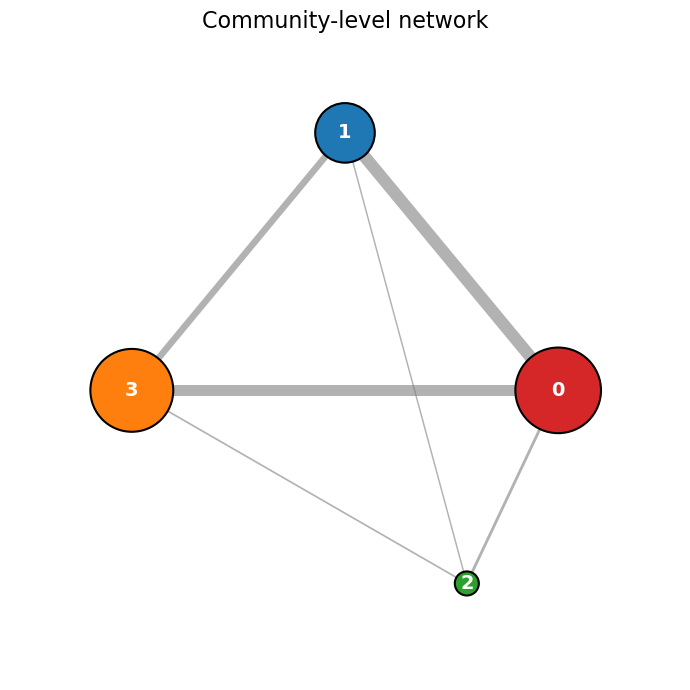

In [32]:
plt.figure(figsize=(7,7))

# layout più stabile e più spazioso
pos = {
    0: (0.9, 0.45),
    1: (0.55, 0.85),
    2: (0.75, 0.15),
    3: (0.2, 0.45)
}

# dimensione nodi (scalata meglio)
node_sizes = [G_comm.nodes[n]['size'] * 20 for n in G_comm.nodes()]

# spessore archi (più leggibile)
edge_widths = [G_comm[u][v]['weight'] / 100 for u, v in G_comm.edges()]

# colori comunità
colors = ["#1f77b4", "#2ca02c", "#d62728", "#ff7f0e"]

# archi
nx.draw_networkx_edges(
    G_comm,
    pos,
    width=edge_widths,
    edge_color="gray",
    alpha=0.6
)

# nodi
nx.draw_networkx_nodes(
    G_comm,
    pos,
    node_size=node_sizes,
    node_color=colors[:len(G_comm.nodes())],
    edgecolors="black",
    linewidths=1.5
)

# etichette
nx.draw_networkx_labels(
    G_comm,
    pos,
    font_size=14,
    font_weight="bold",
    font_color="white"
)

plt.title("Community-level network", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.xlim(0,1.1)
plt.ylim(0,1)
plt.show()

# 7. Machine Learning Task on the Newtork

### Problem Definition

To further investigate the structural properties of the network, we formulate a node classification task. The goal is to predict the community membership of each node, where communities are defined using the Louvain community detection algorithm.

More specifically, the task consists in assigning each node to its corresponding community based on information derived from the network structure.

This problem is well suited to the dataset because community membership reflects the mesoscopic organization of the network, capturing groups of nodes that are more densely connected to each other than to the rest of the graph.

#### Baseline Model: Structural Feature-Based Classification

As a baseline approach, we first train a classifier using handcrafted structural features extracted from the network.

The following node-level metrics are used as input features:

- degree centrality
- betweenness centrality
- closeness centrality
- PageRank
- clustering coefficient
- number of triangles
- in-degree
- out-degree

These measures capture different aspects of a node's structural role in the network, including connectivity, brokerage position, influence, and local cohesion.

A *Random Forest classifier* is trained on these features, using class-balanced learning to mitigate class imbalance among communities.

The model achieves an accuracy of approximately 0.56, with a macro-averaged F1-score close to 0.56. While these results indicate that structural node descriptors contain some information about community membership, the performance remains moderate.

This suggests that simple node-level summary measures are not sufficient to fully capture the structural patterns that define communities in the network.

#### Graph Representation Learning: Node2Vec

To better exploit the relational structure of the graph, we apply *Node2Vec*, a graph embedding algorithm that learns vector representations of nodes directly from the network topology.

Node2Vec generates embeddings by performing biased random walks over the graph and applying a skip-gram model similar to those used in natural language processing. Nodes that appear in similar structural contexts are mapped to nearby points in the embedding space.

The algorithm produces a low-dimensional representation for each node, capturing both local and higher-order structural relationships within the network.

These learned embeddings are then used as input features for a logistic regression classifier, which predicts the community label of each node.

#### Results

The Node2Vec-based approach significantly outperforms the baseline model based on handcrafted structural features.

The classifier achieves:
* Accuracy: 0.96
* Macro F1-score: 0.95

Performance is consistently high across all communities, indicating that the learned embeddings effectively capture the structural patterns that characterize different groups in the network.

The comparison between the two approaches is summarized below:
| Approach | Input representation        | Classifier          | Accuracy | Macro F1 |
| -------- | --------------------------- | ------------------- | -------- | -------- |
| Baseline | Structural network features | Random Forest       | 0.56     | 0.56     |
| Graph ML | Node2Vec embeddings         | Logistic Regression | 0.96     | 0.95     |


### Discussion

The substantial performance improvement obtained with Node2Vec highlights the importance of using representation learning methods specifically designed for graph data.

While traditional structural features such as centrality measures summarize certain aspects of node importance or connectivity, they provide only a limited and partially redundant view of network structure.

In contrast, Node2Vec learns node representations directly from patterns of connectivity in the graph, capturing richer structural information such as shared neighborhoods and higher-order relational structures.

As a result, the embeddings encode community-related patterns much more effectively, enabling the classifier to distinguish between groups with high accuracy.

It should also be noted that the target labels used in the classification task are derived from the Louvain community detection algorithm. Therefore, the task should not be interpreted as predicting an external ground-truth label, but rather as evaluating how well different node representations are able to recover the mesoscopic structure of the network.

#### Conclusion

Overall, the results demonstrate that graph representation learning techniques provide a much more informative representation of node structure than manually engineered features. The Node2Vec embeddings successfully capture the structural signals associated with community membership, leading to near-perfect classification performance.

This comparison illustrates the advantage of using machine learning methods specifically designed for graph data when analyzing complex network structures.

----------------------

### Baseline classifier: RF using handcrafted network features.

I formulated a node classification problem on the network.
Specifically, the task consists in predicting the Louvain community membership of each node based on its structural properties in the graph.

As input features, a set of standard network measures previously computed in the analysis was used:

- degree centrality
- betweenness centrality
- closeness centrality
- PageRank
- local clustering coefficient

These features summarize different aspects of a node’s structural position, including local connectivity, brokerage role, global accessibility, influence, and neighborhood cohesion.

A Random Forest classifier was then trained on these node-level features and evaluated its predictive performance on a held-out test set using accuracy, precision, recall, and F1-score.

The goal of this task is to assess whether the structural profile of a node is informative enough to recover its community membership

In [33]:
# Clustering coefficient on the undirected graph
clustering_dict = nx.clustering(G_und)

# Copy centrality dataframe
ml_df = centrality_df.copy()

# Add clustering coefficient
ml_df["clustering"] = ml_df["node"].map(clustering_dict)

# Add community label as target
ml_df["community"] = ml_df["node"].map(community_map)

# remove community 2 (has only 4 nodes)
ml_df = ml_df[ml_df["community"] != 2]

# add triangles number
triangles = nx.triangles(G_und)
ml_df["triangles"] = ml_df["node"].map(triangles)

# Check missing values
print(ml_df.isnull().sum())

# Preview
ml_df.head()

node                      0
degree_centrality         0
betweenness_centrality    0
closeness_centrality      0
pagerank                  0
in_degree                 0
out_degree                0
label                     0
community                 0
clustering                0
triangles                 0
dtype: int64


,node,degree_centrality,betweenness_centrality,closeness_centrality,pagerank,in_degree,out_degree,label,community,clustering,triangles
0,0,0.069620,0.000733,0.454023,0.001237,26,20,SenatorBaldwin,1,0.329545,174
1,4,0.097046,0.001310,0.481218,0.001514,30,35,SenBlumenthal,1,0.303382,314
3,18,0.067511,0.000796,0.459302,0.001754,25,20,SenCortezMasto,1,0.342742,170
4,25,0.124473,0.002850,0.506952,0.001870,40,41,SenatorDurbin,1,0.285798,489
5,30,0.113924,0.003436,0.520879,0.001214,32,29,LindseyGrahamSC,1,0.239693,343


In [34]:
# x and y
feature_cols = [
    "degree_centrality",
    "betweenness_centrality",
    "closeness_centrality",
    "pagerank",
    "clustering",
    "triangles",
    "in_degree",
    "out_degree"
]

X = ml_df[feature_cols]
y = ml_df["community"]

In [35]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training nodes:", len(X_train))
print("Test nodes:", len(X_test))

Training nodes: 322
Test nodes: 138


In [36]:
# Training
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=200,
                       random_state=42)

In [37]:
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.5652173913043478

Classification report:

              precision    recall  f1-score   support

           0       0.56      0.58      0.57        57
           1       0.49      0.61      0.54        28
           3       0.64      0.53      0.58        53

    accuracy                           0.57       138
   macro avg       0.56      0.57      0.56       138
weighted avg       0.57      0.57      0.57       138



In [38]:
# cm
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"true_{c}" for c in sorted(y.unique())],
    columns=[f"pred_{c}" for c in sorted(y.unique())]
)

cm_df


,pred_0,pred_1,pred_3
true_0,33,10,14
true_1,9,17,2
true_3,17,8,28


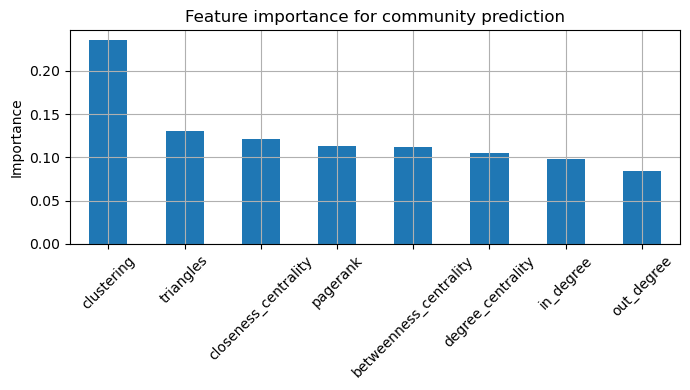

In [39]:
# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(7,4))
importances.plot(kind="bar")
plt.ylabel("Importance")
plt.title("Feature importance for community prediction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Comment on Feature Importance

The feature importance analysis highlights the local clustering coefficient as the most informative predictor of community membership, followed by the number of triangles associated with each node. Both measures capture aspects of triadic closure, a fundamental mechanism in social network formation whereby nodes connected to the same neighbors tend to form closed triangles.

This result suggests that community membership in the network is strongly associated with locally cohesive interaction patterns, rather than with purely global centrality measures such as degree or betweenness centrality. In other words, nodes belonging to the same community tend to participate in dense clusters of mutual interactions.

In [40]:
# cross validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=5,
    scoring="f1_macro"
)

print("F1 macro scores:", cv_scores)
print("Mean F1 macro:", cv_scores.mean())

F1 macro scores: [0.46830787 0.43677019 0.48340259 0.51787218 0.44400803]
Mean F1 macro: 0.4700721709776771


#### Baseline model Results

After removing the extremely small community (community 2) and introducing class-balanced learning, the Random Forest classifier achieves an accuracy of approximately 0.56, with a macro-averaged F1-score close to 0.56. This represents a clear improvement over the baseline model and indicates that correcting class imbalance substantially improves the model’s ability to detect minority communities.

The confusion matrix shows a relatively balanced performance across the three remaining communities. In particular, community 1 achieves the highest recall (0.61), suggesting that the class-weighting strategy effectively mitigates the bias toward larger classes. Communities 0 and 3 are also identified with comparable recall values (0.54 and 0.55 respectively), indicating that the classifier captures structural differences between these groups.

The feature importance analysis highlights the local clustering coefficient as the most informative predictor of community membership, followed by PageRank and closeness centrality. This suggests that local network cohesion plays a key role in distinguishing communities, while simple degree-based measures contribute less to the classification task.

Overall, the results show that node-level structural features contain meaningful information about community structure, although they do not fully capture the higher-order connectivity patterns that define communities in complex networks.

### Training with PCA

#### Principal Component Analysis

To investigate correlations among node-level structural features, we applied Principal Component Analysis (PCA) after standardizing the input variables.

The results show that the first principal component alone explains approximately 69% of the total variance, while the first three components together explain more than 92% of the variance. This indicates that many of the structural features used in the analysis are strongly correlated and capture similar aspects of node connectivity.

The first principal component can be interpreted as a general measure of node embeddedness within the network, combining information related to local clustering, triadic closure, and centrality.

The PCA projection of the nodes reveals that the different communities are only partially separable in the reduced feature space, with substantial overlap between groups. This is consistent with the moderate classification performance observed in the Random Forest model.

Moreover, the classification performance obtained using the PCA-transformed features is very similar to that achieved using the original features, suggesting that the Random Forest classifier is already able to effectively handle correlated input variables.

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# standardizzazione
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

[0.6950177  0.12432532 0.10093484]
Total variance explained: 0.9202778587483613


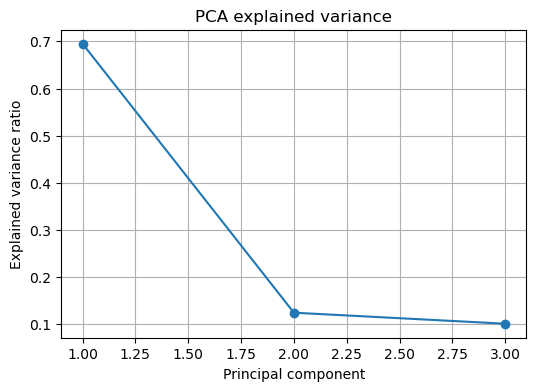

In [42]:
plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA explained variance")

plt.show()

In [43]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# rf model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=200,
                       random_state=42)

In [44]:
# Evaluation: accuracy
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5579710144927537
              precision    recall  f1-score   support

           0       0.58      0.53      0.55        57
           1       0.46      0.64      0.54        28
           3       0.62      0.55      0.58        53

    accuracy                           0.56       138
   macro avg       0.55      0.57      0.56       138
weighted avg       0.57      0.56      0.56       138



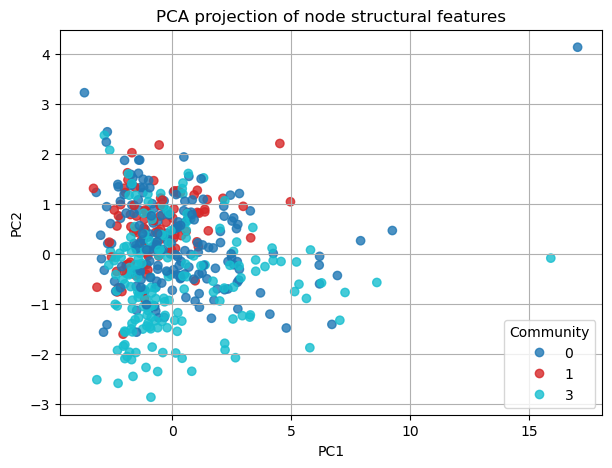

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap="tab10",
    alpha=0.8
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of node structural features")

plt.legend(*scatter.legend_elements(), title="Community")

plt.show()

## Graph ML Model

In [46]:
from node2vec import Node2Vec

node2vec = Node2Vec(
    G_und,
    dimensions=64,
    walk_length=30,
    num_walks=200,
    workers=2,
    seed=42
)

model = node2vec.fit(window=10, min_count=1)

embeddings = {node: model.wv[str(node)] for node in G_und.nodes()}

Computing transition probabilities:   0%|          | 0/475 [00:00<?, ?it/s]

In [ ]:
# dataset
X = []
y = []

for node in ml_df["node"]:
    X.append(embeddings[node])
    y.append(ml_df.loc[ml_df["node"] == node, "community"].values[0])

X = np.array(X)
y = np.array(y)

In [49]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [50]:
# classifier
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=2000)

clf.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [51]:
# evaluation
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97        57
           1       0.96      0.86      0.91        28
           3       0.96      0.98      0.97        53

    accuracy                           0.96       138
   macro avg       0.96      0.94      0.95       138
weighted avg       0.96      0.96      0.96       138



### Node2Vec-based Node Classification

To better align the machine learning task with the graph nature of the data, we applied a Node2Vec embedding approach and used the resulting node representations as input to a logistic regression classifier.

The results are substantially better than those obtained with the baseline Random Forest model based on handcrafted structural features. In particular, the Node2Vec-based classifier achieves an accuracy of 0.96 and a macro-averaged F1-score of 0.95, with very strong performance across all communities.

This large improvement suggests that community membership is strongly encoded in the network topology, but cannot be fully recovered by standard node-level summary measures alone. While centrality, clustering, and triangle counts provide useful but partial information, Node2Vec captures richer structural patterns by learning node embeddings from random walks over the graph.

Overall, the comparison shows that graph representation learning methods are far more effective than manually engineered topological features for this node classification task.

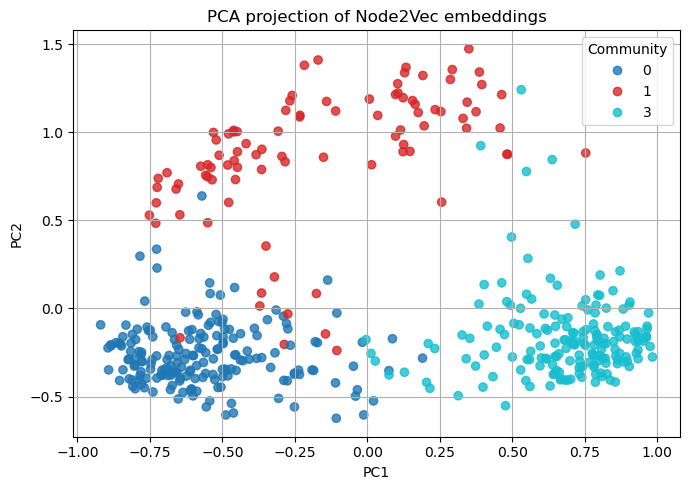

Explained variance ratio: [0.10742523 0.0724701 ]
Total explained variance: 0.17989533


In [57]:
from sklearn.decomposition import PCA

nodes = list(ml_df["node"])
X_emb = np.array([embeddings[n] for n in nodes])
y_emb = ml_df["community"].values

pca_emb = PCA(n_components=2)
X_emb_2d = pca_emb.fit_transform(X_emb)

plt.figure(figsize=(7,5))
scatter = plt.scatter(
    X_emb_2d[:, 0],
    X_emb_2d[:, 1],
    c=y_emb,
    alpha=0.8,
    cmap="tab10"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of Node2Vec embeddings")
plt.legend(*scatter.legend_elements(), title="Community")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca_emb.explained_variance_ratio_)
print("Total explained variance:", pca_emb.explained_variance_ratio_.sum())

#### Comment on Embedding Visualization

To better understand the structure captured by the Node2Vec embeddings, we projected the learned node representations into two dimensions using Principal Component Analysis. The resulting visualization reveals that nodes belonging to the same community tend to cluster together in the embedding space, while nodes from different communities occupy distinct regions.

This clear separation indicates that Node2Vec successfully captures the structural patterns associated with community membership. The embedding space therefore provides a highly informative representation of node positions in the network, which explains the strong performance of the classification model.